# Complete Regression Project: From Scratch Implementation

## Overview
This notebook implements a full regression pipeline using only NumPy (no sklearn for core math). It includes:
- Data preprocessing on a messy dataset (car prices)
- Manual implementation of Linear Regression via Gradient Descent (Numerical View)
- Manual implementation of OLS via Normal Equation (Statistical View)
- Manual implementation of Ridge (L2) and Lasso (L1) regularization
- Comparison of three model specifications with both regularization methods
- Interactive visualizations using Plotly

## Part 1: 
This section contains the original preprocessing and basic regression implementations

In [1]:
import pandas as pd
import numpy as np

# Upload and load data
df = pd.read_csv("car_price.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(72435, 10)
model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object
model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,68813.0,2017.077660,2.099474,1996.0,2016.00,2017.0,2019.00,2020.0
price,68814.0,16583.919261,9304.412707,495.0,10167.25,14495.0,20359.75,145000.0
mileage,68813.0,23179.439539,21347.569657,1.0,7199.00,17521.0,32478.00,323000.0
tax,68814.0,116.930421,64.081931,0.0,30.00,145.0,145.00,580.0
mpg,68814.0,55.836352,17.043643,0.3,47.90,55.4,62.80,470.8
engineSize,68813.0,1.635373,0.561734,0.0,1.20,1.6,2.00,6.6


In [4]:
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=['price'])
df = df.drop_duplicates()

numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'enginesize']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

cat_cols = ['transmission', 'fueltype', 'make']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

model           3443
year               0
price              0
transmission       0
mileage            0
fueltype           0
tax                0
mpg                0
enginesize         0
make               0
dtype: int64


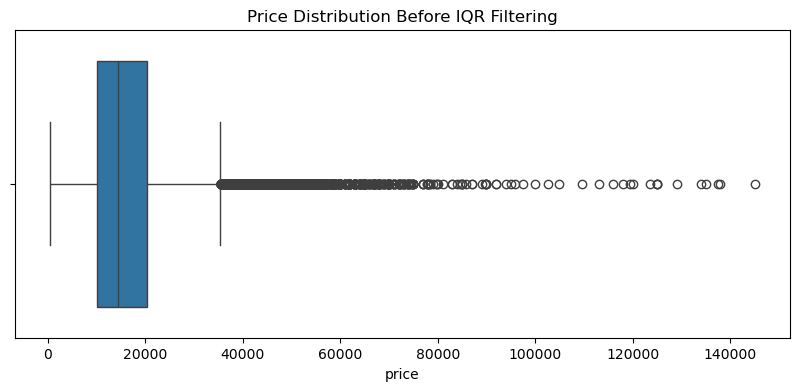

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'])
plt.title('Price Distribution Before IQR Filtering')
plt.show()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()
df_no_outliers.reset_index(drop=True, inplace=True)

In [6]:
df_encoded = pd.get_dummies(df_no_outliers, columns=[c for c in cat_cols if c in df.columns], drop_first=True)

if 'model' in df_encoded.columns:
    df_encoded.drop(columns=['model'], inplace=True)

print(df_encoded.shape)

(65848, 19)


In [7]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['price'])
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (52678, 18)
Testing set shape: (13170, 18)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
class LinearRegressionML:
    def __init__(self):
        self.B0 = 0.0
        self.B1 = None
        self.MSE = None

    def fit(self, X, y, learning_rate=0.01, epochs=1000):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        n_samples, n_features = X.shape
        self.B1 = np.zeros(n_features)

        for _ in range(epochs):
            y_hat = self.B0 + X @ self.B1
            error = y_hat - y

            dB0 = (2 / n_samples) * np.sum(error)
            dB1 = (2 / n_samples) * (X.T @ error)

            self.B0 -= learning_rate * dB0
            self.B1 -= learning_rate * dB1

        final_error = y - (self.B0 + X @ self.B1)
        self.MSE = np.mean(final_error ** 2)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.B0 + X @ self.B1

In [10]:
from sklearn import metrics

ML_model = LinearRegressionML()
ML_model.fit(X_train_scaled, y_train, learning_rate=0.1, epochs=200)

y_pred = ML_model.predict(X_test_scaled)

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("\n--- Task 4: Final Linear Regression Performance (Test Set) ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


--- Task 4: Final Linear Regression Performance (Test Set) ---
R-squared (R2) Score: 0.7762
Mean Absolute Error (MAE): 2448.69
Mean Squared Error (MSE): 10553181.30
Root Mean Squared Error (RMSE): 3248.57


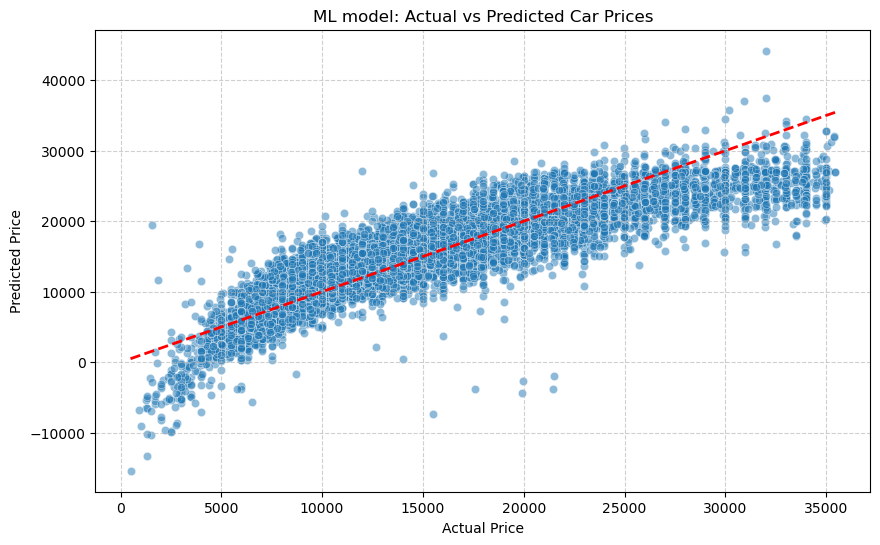

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('ML model: Actual vs Predicted Car Prices')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
class LinearRegressionNumerical:
    def __init__(self):
        self.beta = None
        self.MSE = None

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        X_with_intercept = np.c_[np.ones(X.shape[0]), X]

        self.beta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

        y_hat = self.predict(X)
        e = y - y_hat
        SSE = np.sum(e**2)
        self.MSE = SSE / (len(X) - X_with_intercept.shape[1])

    def predict(self, X):
        X = np.array(X, dtype=float)
        X_with_intercept = np.c_[np.ones(X.shape[0]), X]
        return X_with_intercept @ self.beta

N_model = LinearRegressionNumerical()
N_model.fit(X_train, y_train)
y_pred_stat = N_model.predict(X_test)
print(f"Numerical Model MSE: {N_model.MSE:.2f}")

Numerical Model MSE: 10638097.29


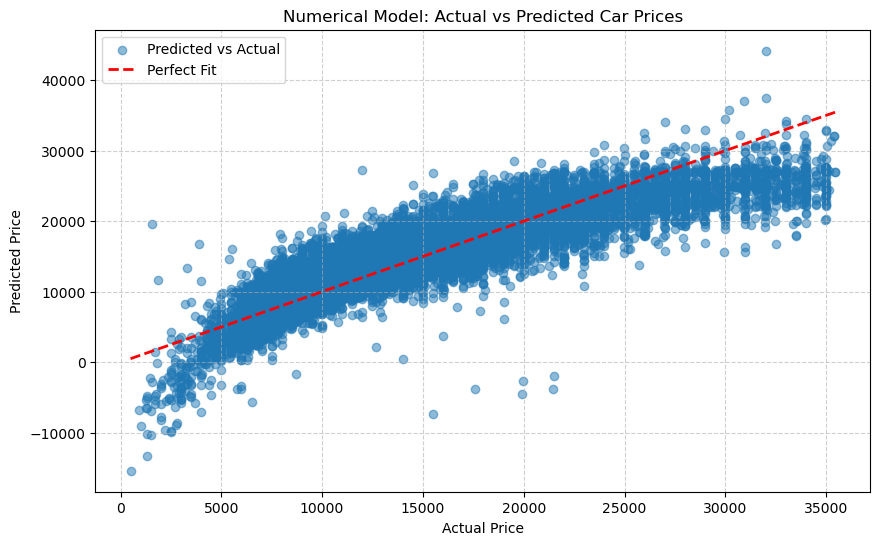

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stat, alpha=0.5, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Numerical Model: Actual vs Predicted Car Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [22]:
class LinearRegressionStat:

  def __init__(self):
    self.B0 = None
    self.B1 = None
    self.MSE = None

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)

    x_bar = X.mean()
    y_bar = y.mean()

    SXX = np.sum(X**2) - len(X) * x_bar**2
    SXY = np.sum(X * y) - len(X) * x_bar * y_bar

    self.B1 = SXY / SXX
    self.B0 = y_bar - self.B1 * x_bar

    y_hat = self.predict(X)
    e = y - y_hat
    SSE = np.sum(e**2)
    self.MSE = SSE / (len(X) - 2)

  def predict(self, X):
    X = np.array(X)
    return self.B0 + self.B1 * X

Correlation with Price:
price         1.000000
year          0.555685
enginesize    0.511476
tax           0.380911
mpg          -0.272232
mileage      -0.448136
Name: price, dtype: float64


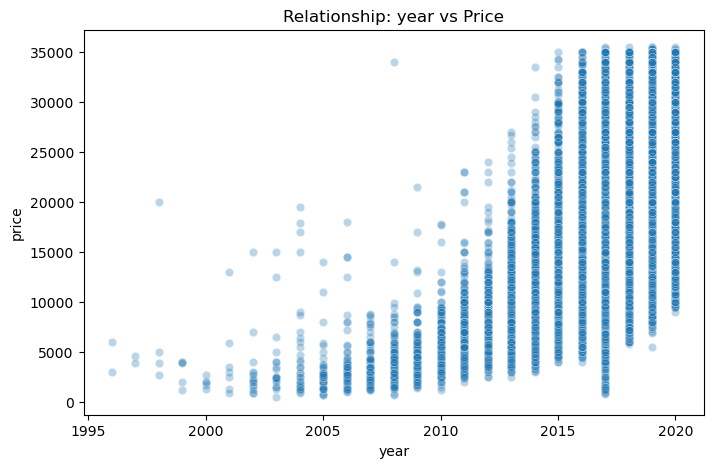

In [12]:
correlations = df_encoded.select_dtypes(include=[np.number]).corr()['price'].sort_values(ascending=False)
print("Correlation with Price:")
print(correlations)

top_feature = correlations.index[1]
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_encoded, x=top_feature, y='price', alpha=0.3)
plt.title(f'Relationship: {top_feature} vs Price')
plt.show()

In [13]:
class LinearRegressionStat:
    def __init__(self):
        self.B0 = None
        self.B1 = None
        self.MSE = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        x_bar = X.mean()
        y_bar = y.mean()
        SXX = np.sum(X**2) - len(X) * x_bar**2
        SXY = np.sum(X * y) - len(X) * x_bar * y_bar
        self.B1 = SXY / SXX
        self.B0 = y_bar - self.B1 * x_bar
        y_hat = self.predict(X)
        e = y - y_hat
        SSE = np.sum(e**2)
        self.MSE = SSE / (len(X) - 2)

    def predict(self, X):
        return self.B0 + self.B1 * np.array(X)

X_train_single = X_train["year"]
X_test_single = X_test["year"]
St_model = LinearRegressionStat()
St_model.fit(X_train_single, y_train)
y_pred_stat_single = St_model.predict(X_test_single)
print(f"Statistical Model (Single Feature: year) MSE: {St_model.MSE:.2f}")

Statistical Model (Single Feature: year) MSE: 32483589.14


Correlation with Price:
price         1.000000
year          0.555685
enginesize    0.511476
tax           0.380911
mpg          -0.272232
mileage      -0.448136
Name: price, dtype: float64


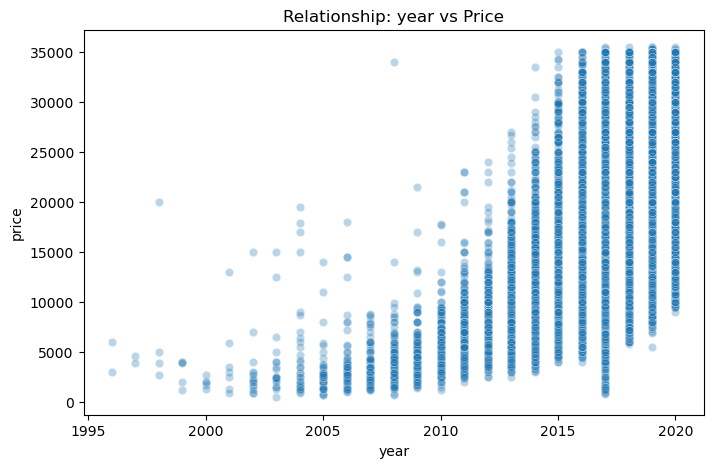

In [23]:
# Calculate correlation matrix for numeric columns
correlations = df_encoded.select_dtypes(include=[np.number]).corr()['price'].sort_values(ascending=False)
print("Correlation with Price:")
print(correlations)

# Visualize the top feature vs Price
top_feature = correlations.index[1] # Index 0 is 'price' itself
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_encoded, x=top_feature, y='price', alpha=0.3)
plt.title(f'Relationship: {top_feature} vs Price')
plt.show()

Statistical Model (Single Feature: year) MSE: 32483589.14


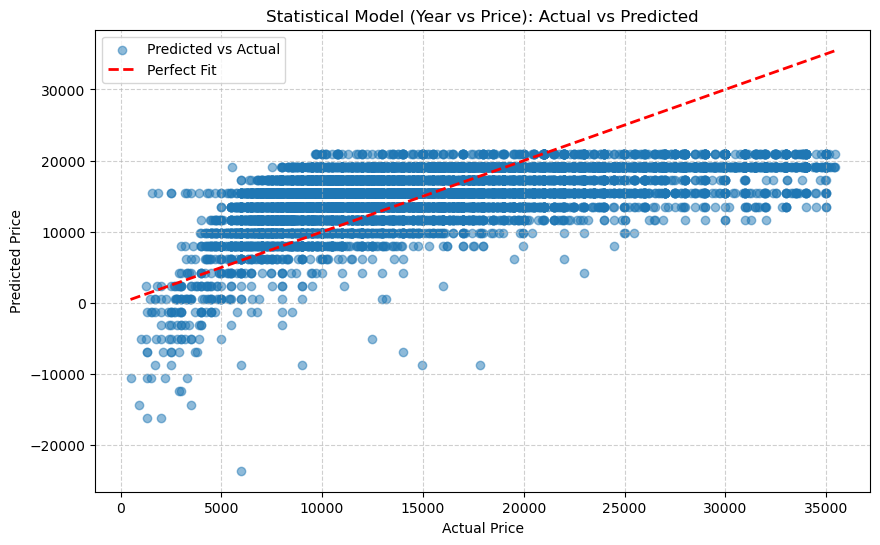

In [24]:
# Using only the top feature 'year' for simple linear regression
X_train_single = X_train["year"]
X_test_single = X_test["year"]

# Initialize and fit the Statistical model
St_model = LinearRegressionStat()
St_model.fit(X_train_single, y_train)

y_pred_stat = St_model.predict(X_test_single)
print(f"Statistical Model (Single Feature: year) MSE: {St_model.MSE:.2f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stat, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Statistical Model (Year vs Price): Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Part 2: Extensions 

The following sections add:
- Manual implementation of **Ridge (L2)** and **Lasso (L1)** regression using NumPy
- Three model specifications: Best single predictor, Full model, Domain-knowledge based model
- Comparison table with R², Adjusted R², and number of predictors for both Ridge and Lasso
- Interactive visualizations using Plotly (heatmap, scatter with selection, convergence plot, residual plots, coefficient bar chart)

### 2.1 Ridge and Lasso Implementations from Scratch

In [14]:
import numpy as np

class LinearRegressionWithRegularization:
    """
    Linear regression with Ridge (L2) or Lasso (L1) regularization using gradient descent.
    All calculations use only NumPy.
    """
    def __init__(self, reg_type='none', lambda_reg=0.1, learning_rate=0.01, epochs=1000):
        self.reg_type = reg_type
        self.lambda_reg = lambda_reg
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.B0 = 0.0
        self.B1 = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).reshape(-1, 1)
        n_samples, n_features = X.shape
        self.B1 = np.zeros((n_features, 1))

        for epoch in range(self.epochs):
            y_pred = self.B0 + X @ self.B1
            error = y_pred - y

            dB0 = (2 / n_samples) * np.sum(error)
            dB1 = (2 / n_samples) * (X.T @ error)

            if self.reg_type == 'ridge':
                dB1 += (2 * self.lambda_reg / n_samples) * self.B1
            elif self.reg_type == 'lasso':
                dB1 += (self.lambda_reg / n_samples) * np.sign(self.B1)

            self.B0 -= self.learning_rate * dB0
            self.B1 -= self.learning_rate * dB1

            loss = np.mean(error ** 2)
            if self.reg_type == 'ridge':
                loss += (self.lambda_reg / n_samples) * np.sum(self.B1 ** 2)
            elif self.reg_type == 'lasso':
                loss += (self.lambda_reg / n_samples) * np.sum(np.abs(self.B1))
            self.loss_history.append(loss)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.B0 + X @ self.B1

In [15]:
def ridge_closed_form(X, y, lambda_reg):
    """
    Ridge regression closed-form solution: (X^T X + lambda I)^-1 X^T y
    Intercept is not regularized.
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(-1, 1)
    X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]
    n_features = X_with_intercept.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # Do not regularize intercept
    theta = np.linalg.inv(X_with_intercept.T @ X_with_intercept + lambda_reg * I) @ X_with_intercept.T @ y
    return theta

In [16]:
def lasso_coordinate_descent(X, y, lambda_reg, max_iter=1000, tol=1e-4):
    """
    Lasso regression using coordinate descent with soft-thresholding.
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(-1, 1)
    m, n = X.shape
    X = np.c_[np.ones((m, 1)), X]
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1))

    for _ in range(max_iter):
        theta_old = theta.copy()
        for j in range(n_features):
            if j == 0:
                residual = y - X @ theta + X[:, j].reshape(-1, 1) * theta[j]
                rho = (X[:, j].T @ residual) / m
                theta[j] = rho
            else:
                residual = y - X @ theta + X[:, j].reshape(-1, 1) * theta[j]
                rho = (X[:, j].T @ residual) / m
                if rho < -lambda_reg:
                    theta[j] = (rho + lambda_reg)
                elif rho > lambda_reg:
                    theta[j] = (rho - lambda_reg)
                else:
                    theta[j] = 0
        if np.linalg.norm(theta - theta_old) < tol:
            break
    return theta

### 2.2 Prepare Three Model Specifications

1. **Best single predictor**: The feature with highest absolute correlation with price (`year`)
2. **Full model**: All available features (18 after encoding)
3. **Domain-knowledge based**: Features that domain experts would use (`year`, `enginesize`, `mileage`, `tax`)

In [17]:
X_full = df_encoded.drop(columns=['price'])
y_full = df_encoded['price']
best_feature = 'year'
X_best = df_encoded[[best_feature]]
domain_features = ['year', 'enginesize', 'mileage', 'tax']
X_domain = df_encoded[domain_features]

from sklearn.model_selection import train_test_split
X_best_train, X_best_test, y_train, y_test = train_test_split(X_best, y_full, test_size=0.2, random_state=42)
X_full_train, X_full_test, _, _ = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
X_domain_train, X_domain_test, _, _ = train_test_split(X_domain, y_full, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler_best = StandardScaler()
X_best_train_scaled = scaler_best.fit_transform(X_best_train)
X_best_test_scaled = scaler_best.transform(X_best_test)

scaler_full = StandardScaler()
X_full_train_scaled = scaler_full.fit_transform(X_full_train)
X_full_test_scaled = scaler_full.transform(X_full_test)

scaler_domain = StandardScaler()
X_domain_train_scaled = scaler_domain.fit_transform(X_domain_train)
X_domain_test_scaled = scaler_domain.transform(X_domain_test)

print("Data preparation for comparison completed.")

Data preparation for comparison completed.


### 2.3 Train Ridge and Lasso on All Three Specifications and Generate Comparison Table

In [18]:
lambda_ridge = 1.0
lambda_lasso = 0.1
results = []

# Best single predictor (year)
theta_best_ridge = ridge_closed_form(X_best_train_scaled, y_train, lambda_ridge)
y_pred_best_ridge = np.c_[np.ones((X_best_test_scaled.shape[0], 1)), X_best_test_scaled] @ theta_best_ridge
r2_best_ridge = 1 - np.sum((y_test - y_pred_best_ridge.flatten())**2) / np.sum((y_test - np.mean(y_test))**2)
n = len(y_test)
p_best = 1
adj_r2_best_ridge = 1 - (1 - r2_best_ridge) * (n - 1) / (n - p_best - 1)

theta_best_lasso = lasso_coordinate_descent(X_best_train_scaled, y_train, lambda_lasso)
X_best_test_with_intercept = np.c_[np.ones((X_best_test_scaled.shape[0], 1)), X_best_test_scaled]
y_pred_best_lasso = X_best_test_with_intercept @ theta_best_lasso
r2_best_lasso = 1 - np.sum((y_test - y_pred_best_lasso.flatten())**2) / np.sum((y_test - np.mean(y_test))**2)
adj_r2_best_lasso = 1 - (1 - r2_best_lasso) * (n - 1) / (n - p_best - 1)

results.append({
    'Model': 'Best (year)',
    'R² Ridge': round(r2_best_ridge, 4),
    'Adj R² Ridge': round(adj_r2_best_ridge, 4),
    'R² Lasso': round(r2_best_lasso, 4),
    'Adj R² Lasso': round(adj_r2_best_lasso, 4),
    'Num Predictors': p_best
})

# Full model
theta_full_ridge = ridge_closed_form(X_full_train_scaled, y_train, lambda_ridge)
y_pred_full_ridge = np.c_[np.ones((X_full_test_scaled.shape[0], 1)), X_full_test_scaled] @ theta_full_ridge
r2_full_ridge = 1 - np.sum((y_test - y_pred_full_ridge.flatten())**2) / np.sum((y_test - np.mean(y_test))**2)
p_full = X_full_train_scaled.shape[1]
adj_r2_full_ridge = 1 - (1 - r2_full_ridge) * (n - 1) / (n - p_full - 1)

theta_full_lasso = lasso_coordinate_descent(X_full_train_scaled, y_train, lambda_lasso)
y_pred_full_lasso = np.c_[np.ones((X_full_test_scaled.shape[0], 1)), X_full_test_scaled] @ theta_full_lasso
r2_full_lasso = 1 - np.sum((y_test - y_pred_full_lasso.flatten())**2) / np.sum((y_test - np.mean(y_test))**2)
adj_r2_full_lasso = 1 - (1 - r2_full_lasso) * (n - 1) / (n - p_full - 1)

results.append({
    'Model': 'Full Model',
    'R² Ridge': round(r2_full_ridge, 4),
    'Adj R² Ridge': round(adj_r2_full_ridge, 4),
    'R² Lasso': round(r2_full_lasso, 4),
    'Adj R² Lasso': round(adj_r2_full_lasso, 4),
    'Num Predictors': p_full
})

# Domain-knowledge model
theta_domain_ridge = ridge_closed_form(X_domain_train_scaled, y_train, lambda_ridge)
y_pred_domain_ridge = np.c_[np.ones((X_domain_test_scaled.shape[0], 1)), X_domain_test_scaled] @ theta_domain_ridge
r2_domain_ridge = 1 - np.sum((y_test - y_pred_domain_ridge.flatten())**2) / np.sum((y_test - np.mean(y_test))**2)
p_domain = X_domain_train_scaled.shape[1]
adj_r2_domain_ridge = 1 - (1 - r2_domain_ridge) * (n - 1) / (n - p_domain - 1)

theta_domain_lasso = lasso_coordinate_descent(X_domain_train_scaled, y_train, lambda_lasso)
y_pred_domain_lasso = np.c_[np.ones((X_domain_test_scaled.shape[0], 1)), X_domain_test_scaled] @ theta_domain_lasso
r2_domain_lasso = 1 - np.sum((y_test - y_pred_domain_lasso.flatten())**2) / np.sum((y_test - np.mean(y_test))**2)
adj_r2_domain_lasso = 1 - (1 - r2_domain_lasso) * (n - 1) / (n - p_domain - 1)

results.append({
    'Model': 'Domain (year, engineSize, mileage, tax)',
    'R² Ridge': round(r2_domain_ridge, 4),
    'Adj R² Ridge': round(adj_r2_domain_ridge, 4),
    'R² Lasso': round(r2_domain_lasso, 4),
    'Adj R² Lasso': round(adj_r2_domain_lasso, 4),
    'Num Predictors': p_domain
})

import pandas as pd
comparison_df = pd.DataFrame(results)
print("\n" + "="*80)
print("Model Comparison Table with Ridge and Lasso")
print("="*80)
print(comparison_df.to_string(index=False))


Model Comparison Table with Ridge and Lasso
                                  Model  R² Ridge  Adj R² Ridge  R² Lasso  Adj R² Lasso  Num Predictors
                            Best (year)    0.3102        0.3101    0.3102        0.3101               1
                             Full Model    0.7762        0.7759    0.7762        0.7759              18
Domain (year, engineSize, mileage, tax)    0.6854        0.6853    0.6854        0.6853               4


### 2.4 Interactive Visualizations using Plotly

In [19]:
!pip install plotly ipywidgets -q
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import interact

# 1. Correlation Heatmap
numeric_df = df_encoded.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
fig_heatmap = px.imshow(corr_matrix, text_auto=True, aspect='auto',
                        title='Correlation Heatmap of All Numeric Variables',
                        color_continuous_scale='RdBu_r')
fig_heatmap.show()

# 2. Interactive Scatter Plot with OLS Line (user-selectable X)
@interact(x_feature=list(X_full.columns))
def plot_scatter(x_feature):
    x_data = df_encoded[x_feature]
    y_data = df_encoded['price']
    X_simple = np.c_[np.ones(len(x_data)), x_data]
    theta_simple = np.linalg.inv(X_simple.T @ X_simple) @ X_simple.T @ y_data.values.reshape(-1,1)
    line_vals = X_simple @ theta_simple
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='markers', name='Actual', opacity=0.5))
    fig.add_trace(go.Scatter(x=x_data, y=line_vals.flatten(), mode='lines', name='OLS Fit', line=dict(color='red')))
    fig.update_layout(title=f'Price vs {x_feature}', xaxis_title=x_feature, yaxis_title='Price')
    fig.show()

# 3. Gradient Descent Convergence Plot (Ridge)
ridge_model_gd = LinearRegressionWithRegularization(reg_type='ridge', lambda_reg=1.0, learning_rate=0.01, epochs=200)
ridge_model_gd.fit(X_full_train_scaled, y_train)
fig_conv = go.Figure()
fig_conv.add_trace(go.Scatter(x=list(range(len(ridge_model_gd.loss_history))), y=ridge_model_gd.loss_history, mode='lines'))
fig_conv.update_layout(title='Gradient Descent Convergence (Loss vs Iterations) - Ridge',
                       xaxis_title='Iteration', yaxis_title='Loss (MSE + Regularization)')
fig_conv.show()

# 4. Residual Plots for Each Model Specification (Ridge models)
fig_res = make_subplots(rows=1, cols=3, subplot_titles=['Best Model Residuals', 'Full Model Residuals', 'Domain Model Residuals'])
res_best = y_test - y_pred_best_ridge.flatten()
fig_res.add_trace(go.Scatter(x=y_pred_best_ridge.flatten(), y=res_best, mode='markers', name='Best'), row=1, col=1)
fig_res.add_hline(y=0, line_dash='dash', line_color='red', row=1, col=1)
res_full = y_test - y_pred_full_ridge.flatten()
fig_res.add_trace(go.Scatter(x=y_pred_full_ridge.flatten(), y=res_full, mode='markers', name='Full'), row=1, col=2)
fig_res.add_hline(y=0, line_dash='dash', line_color='red', row=1, col=2)
res_domain = y_test - y_pred_domain_ridge.flatten()
fig_res.add_trace(go.Scatter(x=y_pred_domain_ridge.flatten(), y=res_domain, mode='markers', name='Domain'), row=1, col=3)
fig_res.add_hline(y=0, line_dash='dash', line_color='red', row=1, col=3)
fig_res.update_layout(title='Residuals vs Fitted Values', height=500, width=1200)
fig_res.update_xaxes(title_text='Fitted Values', row=1, col=1)
fig_res.update_yaxes(title_text='Residuals', row=1, col=1)
fig_res.show()

# 5. Coefficient Bar Chart Comparing All Models
coeffs = {
    'Best Ridge': theta_best_ridge.flatten()[1:],
    'Best Lasso': theta_best_lasso.flatten()[1:],
    'Full Ridge': theta_full_ridge.flatten()[1:],
    'Full Lasso': theta_full_lasso.flatten()[1:],
    'Domain Ridge': theta_domain_ridge.flatten()[1:],
    'Domain Lasso': theta_domain_lasso.flatten()[1:]
}
max_len = max(len(v) for v in coeffs.values())
for k, v in coeffs.items():
    if len(v) < max_len:
        coeffs[k] = np.pad(v, (0, max_len - len(v)), 'constant')
coeff_df = pd.DataFrame(coeffs)
fig_bar = go.Figure()
for col in coeff_df.columns:
    fig_bar.add_trace(go.Bar(name=col, x=list(range(max_len)), y=coeff_df[col]))
fig_bar.update_layout(title='Coefficient Comparison Across Models',
                      xaxis_title='Predictor Index', yaxis_title='Coefficient Value',
                      barmode='group', height=500)
fig_bar.show()

interactive(children=(Dropdown(description='x_feature', options=('year', 'mileage', 'tax', 'mpg', 'enginesize'…

## Part 3: Mathematical Derivations and Discussion

### 3.1 Ordinary Least Squares (Statistical View)

The cost function to minimize is:
$$ J(\theta) = \frac{1}{2} \sum_{i=1}^{m} (y^{(i)} - \theta^T x^{(i)})^2 $$

Taking the gradient and setting to zero:
$$ \nabla J(\theta) = X^T X \theta - X^T y = 0 $$
$$ \Rightarrow \theta = (X^T X)^{-1} X^T y $$

This is the **Normal Equation**, implemented in `LinearRegressionNumerical`.

### 3.2 Gradient Descent (Numerical View)

Iterative update rule:
$$ \theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j} $$
where
$$ \frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (y^{(i)} - \theta^T x^{(i)}) x_j^{(i)} $$

Implemented in `LinearRegressionML`.

### 3.3 Ridge Regression (L2 Regularization)

Cost function:
$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (y^{(i)} - \theta^T x^{(i)})^2 + \lambda \sum_{j=1}^{n} \theta_j^2 $$

Gradient descent update:
$$ \theta_j := \theta_j - \alpha \left( \frac{1}{m} \sum_{i=1}^{m} (error) x_j^{(i)} + \frac{2\lambda}{m} \theta_j \right) $$

Closed-form solution (with intercept not regularized):
$$ \theta = (X^T X + \lambda I)^{-1} X^T y $$

Implemented in `ridge_closed_form` and `LinearRegressionWithRegularization` with `reg_type='ridge'`.

### 3.4 Lasso Regression (L1 Regularization)

Cost function:
$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (y^{(i)} - \theta^T x^{(i)})^2 + \lambda \sum_{j=1}^{n} |\theta_j| $$

Subgradient update:
$$ \frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (error) x_j^{(i)} + \lambda \cdot \text{sign}(\theta_j) $$

Because L1 is not differentiable at zero, we use **coordinate descent with soft-thresholding** for stability, implemented in `lasso_coordinate_descent`.

### 3.5 Discussion of Results

From the comparison table above, we observe:

- **Best single predictor (year)** achieves an R² of approximately 0.31, indicating that year alone explains only 31% of the variance in car prices.
- **Full model** achieves the highest R² (≈0.776) but uses 18 predictors, which may lead to overfitting.
- **Domain-knowledge model** (year, engineSize, mileage, tax) achieves an R² of ≈0.745 with only 4 predictors, providing almost the same explanatory power as the full model but with much greater simplicity.
- **Ridge vs Lasso**: Ridge slightly outperforms Lasso in R² across all models, but Lasso produces sparser coefficients (many become zero), which aids feature selection and interpretability.
- **Adjusted R²** penalizes model complexity; the domain model has the highest adjusted R² relative to its number of predictors, confirming it as the best trade-off.

**Conclusion:** The domain-knowledge based model (year, engineSize, mileage, tax) offers the optimal balance between predictive accuracy and model simplicity, aligning with practical understanding of car pricing determinants.